# Cosmic-ray transport equation solver
## **Advection and diffusion**

#### Imports

In [1]:
include("../Code/CRT_tools_3D.jl");
include("../Code/CRT_func_3D.jl");

#### Constants

In [2]:
const pc = 3e18;
const kpc = 1e3 * pc;

#### Grid definition

In [3]:
nr, nz, np = 40, 41, 10;

r_min, r_max = pc, kpc;
z_min, z_max = pc, kpc;
p_min, p_max = 1.0, 1e6;

r_list, z_list, p_list, pu_list = make_grids(nr, nz, np, r_min, r_max, z_min, z_max, p_min, p_max);

#### Physical parameters

In [4]:
v_w = 1e7; # cm/s
L = z_list[end];
Q_0 = 1.0;
f = 0.1;
D_0 = 1e28;

#### Functions for diffusion coefficient and wind velocity (advection)

In [5]:
Dz(r, z, p) = f * D_0;
v_z(z) = v_w * sign(z);

#### Analytical solution for axial diffusion and advection 

In [6]:
function N_adv_diff(r::Float64, z::Float64, p::Float64)
    w = - v_w * L / Dz(r, z, p)
    w_fac = w * (1.0 - (abs(z) / L))
    if abs(w_fac) <= 1e-2
        num = abs(w_fac)
    else
        num = 1.0 - exp(w_fac)
    end
    den = 1.0 - exp(w)
    N_0 = (Q_0 / (2 * v_w)) * (1.0 - exp(w))
    return N_0 * num / den
end


N_sol_adv_diff = zeros(nz) 

for j in eachindex(z_list)
    N_sol_adv_diff[j] = N_adv_diff(1.0, z_list[j], 1.0)
end

#### Source term

In [7]:
function Q_adv_diff(r::Float64, z::Float64, p::Float64)
    if z==z_list[length(z_list)÷2+1] || z==z_list[length(z_list)÷2] || z==z_list[length(z_list)÷2+2]
        dZ1 = 2 * z_list[length(z_list)÷2+2]
        bin_factor =  dZ1
        return (Q_0 / bin_factor) 
    else
        return 0
    end
end


Q_arr_adv_diff = zeros(nr, nz, np)

for k in eachindex(p_list)
    for j in eachindex(z_list)
        for i in eachindex(r_list)
            Q_arr_adv_diff[i, j, k] = Q_adv_diff(r_list[i], z_list[j], p_list[k])
        end
    end
end

#### Time step definition

In [8]:
m = 10;
Dt_list = make_dt_list(1e9, m);

Total physical time = 1.0998937565353476e15
No. of different Dts = 97


### **Transport equation solver**

In [9]:
prev_sol = zeros(nr, nz, np)

for it in eachindex(Dt_list)

    Dt = Dt_list[it]

    A_nextz, A_nz = make_Az(r_list, z_list, p_list, Dz, v_z, Dt)

    for n in 1:m

        global prev_sol

        B_nz = make_Bz(A_nz, prev_sol, Q_arr_adv_diff, Dt)
        Threads.@threads for k in 1:np
            @simd for i in 1:nr
                @inbounds prev_sol[i, :, k] = A_nextz[i, k] \ B_nz[i, k, :]
          end
        end 
    
    end

end

#### Plot using Julia

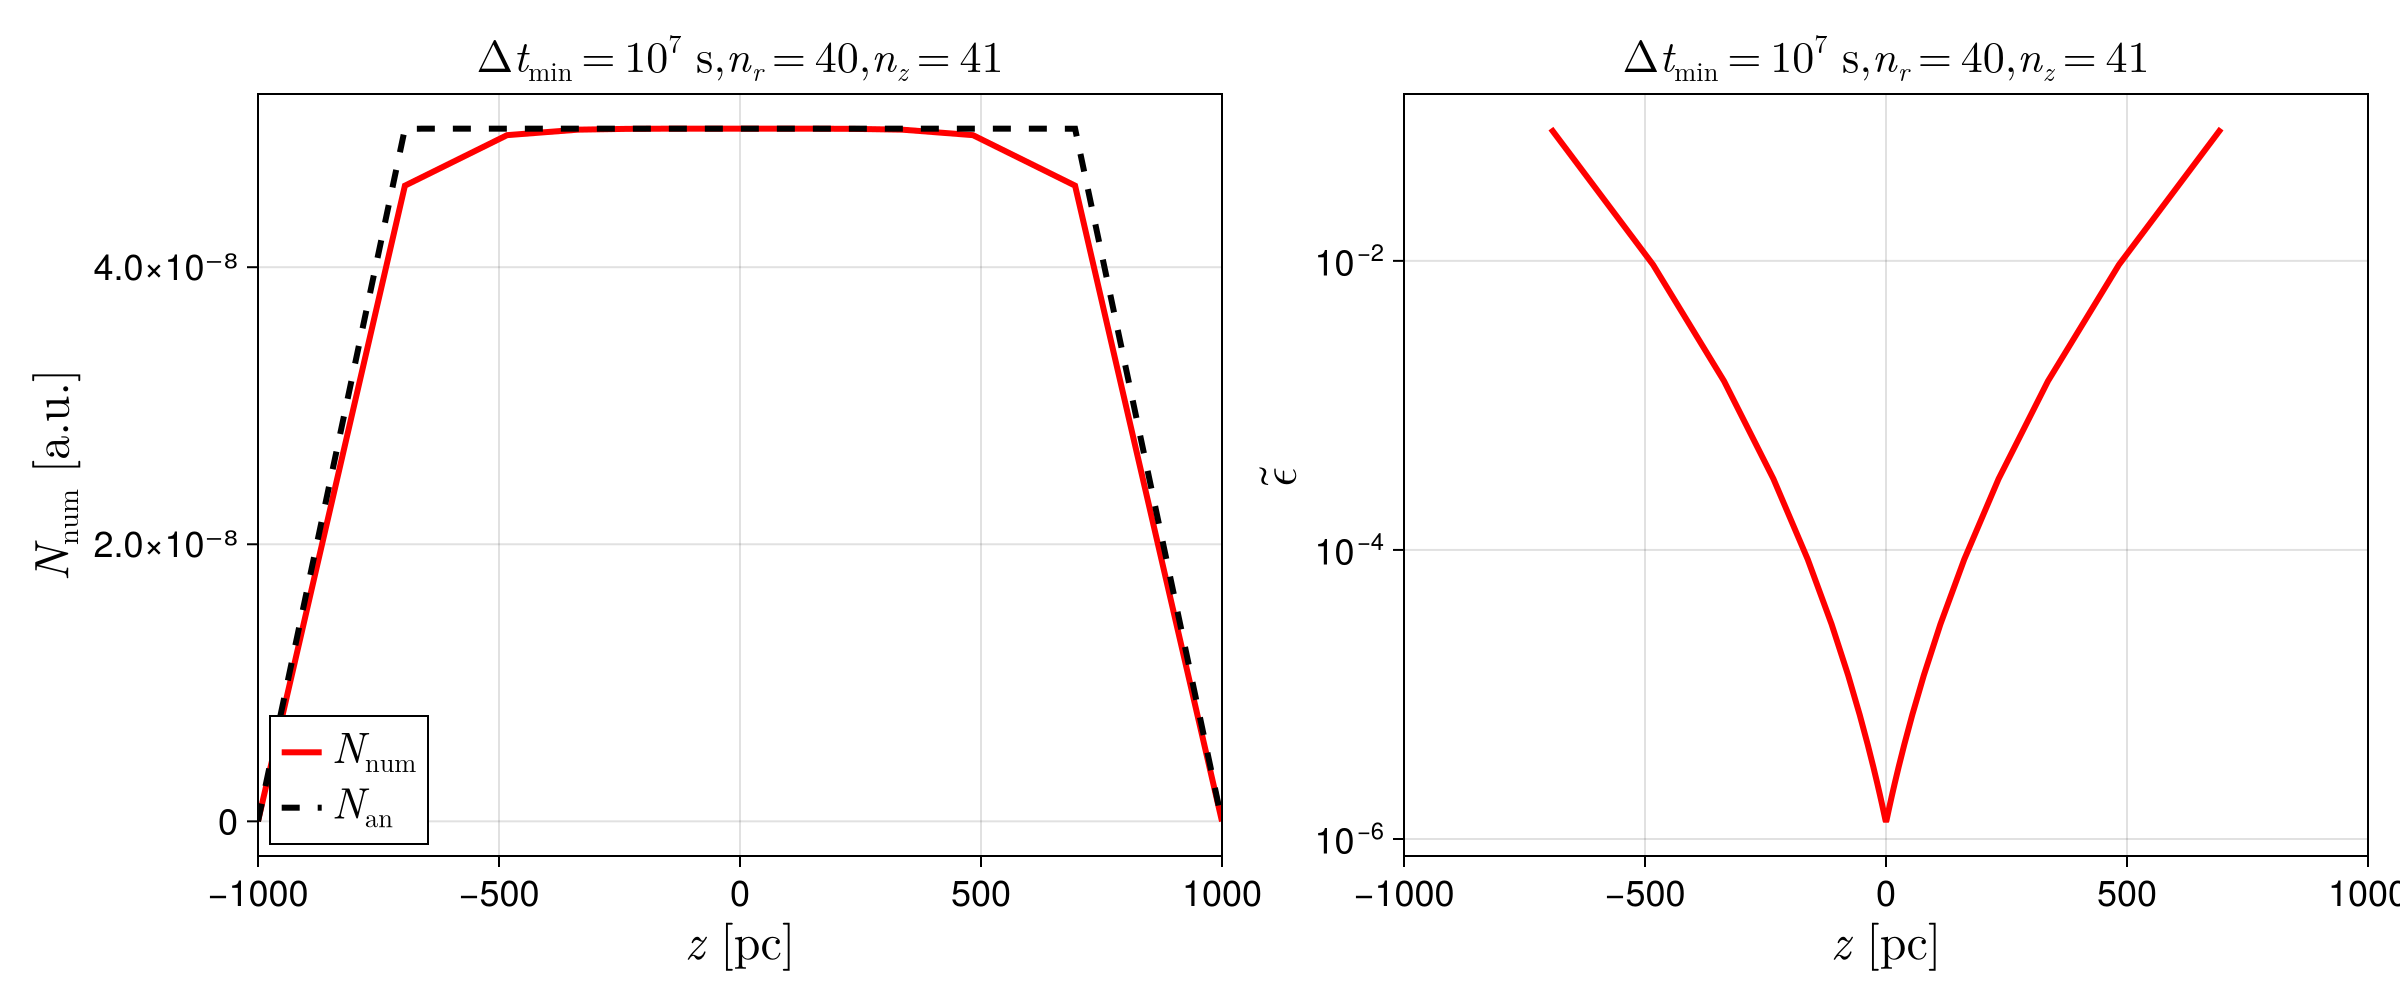

In [11]:
using CairoMakie

z = z_list ./ pc

fig = Figure(size = (1200, 500), fontsize = 22)

# ---------------- LEFT: SOLUTION ----------------
ax1 = Axis(fig[1, 1],
    xlabel = L"z~[\mathrm{pc}]",
    ylabel = L"N_{\mathrm{num}}~[\mathrm{a.u.}]",
    title = L"\Delta t_{\mathrm{min}}=10^7~\mathrm{s}, n_r=40, n_z=41",
    limits = ((-1000, 1000), nothing),
    xlabelsize = 24,
    ylabelsize = 24,
    titlesize = 22,
    xticklabelsize = 18,
    yticklabelsize = 18
)

lines!(ax1, z, prev_sol[1, :, 1], color = :red, linewidth = 3, label = L"N_{\mathrm{num}}") # numerical (solid)
lines!(ax1, z, N_sol_adv_diff, color = :black, linestyle = :dash, linewidth = 3, label = L"N_{\mathrm{an}}") # analytical (dashed)

axislegend(ax1, position = :lb, fontsize = 18)

# ---------------- RIGHT: ERROR ----------------
err = abs.(N_sol_adv_diff .- prev_sol[1, :, 1]) ./ N_sol_adv_diff

ax2 = Axis(fig[1, 2],
    xlabel = L"z~[\mathrm{pc}]",
    ylabel = L"\tilde{\epsilon}",
    title = L"\Delta t_{\mathrm{min}}=10^7~\mathrm{s}, n_r=40, n_z=41",
    xscale = identity,
    yscale = log10,
    limits = ((-1000, 1000), nothing),
    xlabelsize = 24,
    ylabelsize = 24,
    titlesize = 22,
    xticklabelsize = 18,
    yticklabelsize = 18
)

lines!(ax2, z, err, color = :red, linewidth = 3)

fig